# Dual Branch UNet — Overview & Experiment Log

> CNN1 of the Precipitation Downsampling project (ADLEO Course)  
> Owner: Bikal

**Goal:** Downscale IMERG satellite precipitation from ~10 km to 250 m resolution over the Big Island of Hawai'i by fusing multi-source geospatial data through a Dual Branch UNet.

**Region:** Big Island of Hawai'i — lon [−156.07, −154.799], lat [18.89, 20.277]  
**Temporal coverage:** 2020 (train), Jan–Jun 2021 (val + test)

In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

BASE_DIR = Path('..').resolve()
sys.path.insert(0, str(BASE_DIR))

from src.models.unet import DualBranchUNet, DualBranchLoss
print('Imports OK')

Imports OK


---
## 1. Data Sources

| Source | Variable | Resolution | Description |
|---|---|---|---|
| NASA IMERG Early Run V07B | Precipitation (mm/day) | 0.1° (~10 km) | Daily satellite precipitation estimates |
| GOES-17 | BCM (Binary Cloud Mask) | ~2 km | Daily cloud cover indicator |
| HCDP Station CSVs | Daily rainfall (mm) | Point (~165 stations) | Ground-truth rain gauge observations |
| SRTM/DEM (`geostack_30m_topo.tif`) | Elevation, Slope, Aspect | 30 m | Topographic stack for Big Island |

---
## 2. Data Pipeline

```
IMERG (.tif)  ──┐
GOES-17 (.nc) ──┼──► process_data.py ──► 5-band input TIF (processed_precip_YYYYMMDD.tif)
DEM (.tif)    ──┘

HCDP stations ──────────────────────────► rasterized_stations/XYYYY.MM.DD.tif

                    create_csv.py
                         ▼
              data/processed/file_paths.csv
                         ▼
                    LoadDataset
                         ▼
              32×32 chips  (input, target, station_mask)
```

### Input Raster Bands (5 channels)

| Band | Source | Branch | Description |
|---|---|---|---|
| 1 | IMERG | Branch 1 | Daily precipitation (mm/day) |
| 2 | GOES-17 | Branch 1 | Binary cloud mask |
| 3 | DEM | Branch 2 | Elevation (m) |
| 4 | DEM | Branch 2 | Slope (degrees) |
| 5 | DEM | Branch 2 | Aspect (degrees) |

### Preprocessing
1. Clip all data to Big Island bounding box
2. Reproject and align all sources to HCDP resolution grid
3. Extract 32×32 chips centered on valid station pixels
4. Min-Max normalize input band 1 and target per chip to [0, 1]
5. Augmentation (train only): random 90° rotations + horizontal/vertical flips

---
## 3. Model Architecture

```
Input (B, 5, 32, 32)
        │
        ├─────────────────────────────────────────────┐
        │  Branch 1 (precip + GOES)                   │  Branch 2 (topo)
        │  in_ch = 2                                  │  in_ch = 3
        │                                             │
        │  ConvBlock(2→32)    (B, 32, 32, 32)         │  ConvBlock(3→32)    (B, 32, 32, 32)
        │  MaxPool2d(2)       (B, 32, 16, 16)         │  MaxPool2d(2)       (B, 32, 16, 16)
        │  ConvBlock(32→64)   (B, 64, 16, 16)         │  ConvBlock(32→64)   (B, 64, 16, 16)
        │  MaxPool2d(2)       (B, 64,  8,  8)         │  MaxPool2d(2)       (B, 64,  8,  8)
        │  ConvBlock(64→128)  (B, 128,  8,  8)        │  ConvBlock(64→128)  (B, 128,  8,  8)
        │  MaxPool2d(2)       (B, 128,  4,  4)        │  MaxPool2d(2)       (B, 128,  4,  4)
        └──────────────── torch.cat(dim=1) ───────────┘
                           (B, 256, 4, 4)
                        ConvBlock(256→256)
                                │
                       ── Shared Decoder ──
                   ConvTranspose2d(256→128)  →  (B, 128, 8, 8)
                       ConvBlock(128→128)
                   ConvTranspose2d(128→64)   →  (B, 64, 16, 16)
                       ConvBlock(64→64)
                   ConvTranspose2d(64→32)    →  (B, 32, 32, 32)
                       ConvBlock(32→32)
                       Conv2d(32→1, 1×1)
                                │
                       Output (B, 1, 32, 32)
```

**Conv Block:** `Conv2d → BN → ReLU → Conv2d → BN → ReLU`

In [2]:
# ── Instantiate model and print summary ────────────────────────────────────
model = DualBranchUNet(branch1_in=2, branch2_in=3)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {n_params:,}')
print()
print(model)

Total trainable parameters: 2,315,553

DualBranchUNet(
  (branch1): EncoderBranch(
    (enc1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (enc2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [3]:
# ── Verify forward pass shape ──────────────────────────────────────────────
dummy = torch.zeros(4, 5, 32, 32)   # batch of 4 chips
with torch.no_grad():
    out = model(dummy)
print(f'Input shape : {dummy.shape}')
print(f'Output shape: {out.shape}')   # expected: (4, 1, 32, 32)

Input shape : torch.Size([4, 5, 32, 32])
Output shape: torch.Size([4, 1, 32, 32])


---
## 4. Loss Function

```
Total Loss = λ₁ · MaskedMSE + λ₂ · TVLoss
```

| Term | Formula | Purpose |
|---|---|---|
| **MaskedMSE** | `mean((pred[mask] − target[mask])²)` | Penalise error only at rain gauge pixels |
| **TVLoss** | `mean(\|row diffs\| + \|col diffs\|)` | Encourage spatially smooth rainfall fields |

| Weight | Default |
|---|---|
| λ₁ (`--lambda-mse`) | 1.0 |
| λ₂ (`--lambda-tv`) | 0.1 |

In [4]:
# ── Demonstrate loss computation ───────────────────────────────────────────
criterion = DualBranchLoss(masked_mse_weight=1.0, tv_weight=0.1)

pred   = torch.rand(4, 1, 32, 32)
target = torch.rand(4, 1, 32, 32)
mask   = torch.rand(4, 1, 32, 32) > 0.9   # ~10% of pixels are stations

total, mse, tv = criterion(pred, target, mask)
print(f'Total loss : {total.item():.4f}')
print(f'Masked MSE : {mse.item():.4f}')
print(f'TV loss    : {tv.item():.4f}')
print(f'Station pixels in batch: {mask.sum().item()} / {mask.numel()}')

Total loss : 0.2416
Masked MSE : 0.1753
TV loss    : 0.6629
Station pixels in batch: 427 / 4096


---
## 5. Training Configuration

| Parameter | Value |
|---|---|
| Device | MPS (Apple Silicon M2 Max GPU) |
| Chip size | 32 × 32 pixels |
| Batch size | 64 |
| DataLoader workers | 8 (persistent) |
| Optimizer | Adam |
| Learning rate | 1e-3 |
| Epochs | 50 |
| Checkpoint strategy | Save on best val loss |

### Data Split

| Split | Period | Days | Chips | Ratio |
|---|---|---|---|---|
| Train | Jan–Dec 2020 | 366 | 13,039 | ~60% |
| Val | Jan–Mar 2021 | 90 | 3,138 | ~15% |
| Test | Apr–Jun 2021 | 91 | 3,242 | ~15% |
| Unused | Jul–Dec 2021 | 184 | — | — |

> Sequential time-based splits — dates are never shuffled to prevent future data leakage.

---
## 6. Experiment Results

| Metric | Value |
|---|---|
| Best val loss | **0.0361** |
| Best epoch | **24 / 50** |
| Final train loss | 0.0303 (mse=0.0299, tv=0.0043) |
| Final val loss | 0.0381 (mse=0.0375, tv=0.0054) |
| Test loss | **0.0332** |

### Loss Breakdown at Best Epoch (Epoch 24)

| Split | Total | MSE | TV |
|---|---|---|---|
| Train | 0.0316 | 0.0311 | 0.0053 |
| Val | 0.0361 | 0.0354 | 0.0069 |

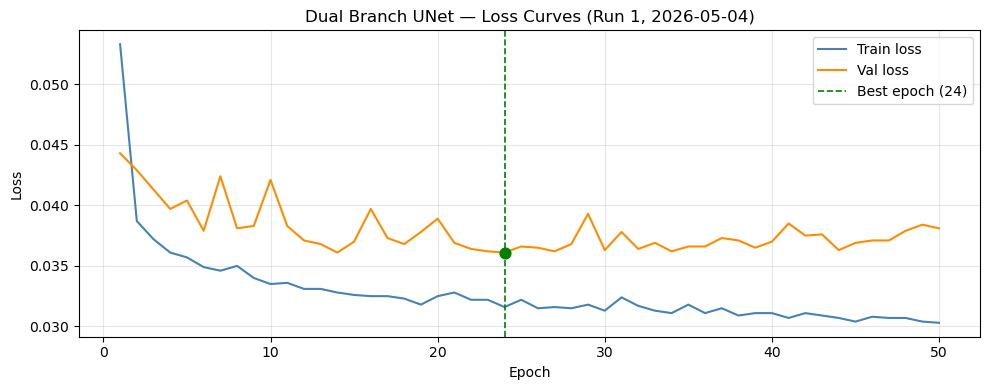

Best val loss: 0.0361 at epoch 14


In [5]:
# ── Reproduce loss curve from logged epoch data ────────────────────────────
train_losses = [
    0.0533,0.0387,0.0372,0.0361,0.0357,0.0349,0.0346,0.0350,0.0340,0.0335,
    0.0336,0.0331,0.0331,0.0328,0.0326,0.0325,0.0325,0.0323,0.0318,0.0325,
    0.0328,0.0322,0.0322,0.0316,0.0322,0.0315,0.0316,0.0315,0.0318,0.0313,
    0.0324,0.0317,0.0313,0.0311,0.0318,0.0311,0.0315,0.0309,0.0311,0.0311,
    0.0307,0.0311,0.0309,0.0307,0.0304,0.0308,0.0307,0.0307,0.0304,0.0303,
]
val_losses = [
    0.0443,0.0429,0.0413,0.0397,0.0404,0.0379,0.0424,0.0381,0.0383,0.0421,
    0.0383,0.0371,0.0368,0.0361,0.0370,0.0397,0.0373,0.0368,0.0378,0.0389,
    0.0369,0.0364,0.0362,0.0361,0.0366,0.0365,0.0362,0.0368,0.0393,0.0363,
    0.0378,0.0364,0.0369,0.0362,0.0366,0.0366,0.0373,0.0371,0.0365,0.0370,
    0.0385,0.0375,0.0376,0.0363,0.0369,0.0371,0.0371,0.0379,0.0384,0.0381,
]
best_epoch = 24

epochs = list(range(1, 51))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs, train_losses, label='Train loss', color='steelblue')
ax.plot(epochs, val_losses,   label='Val loss',   color='darkorange')
ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch ({best_epoch})')
ax.scatter([best_epoch], [val_losses[best_epoch-1]], color='green', zorder=5, s=60)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Dual Branch UNet — Loss Curves (Run 1, 2026-05-04)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best val loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses))+1}')

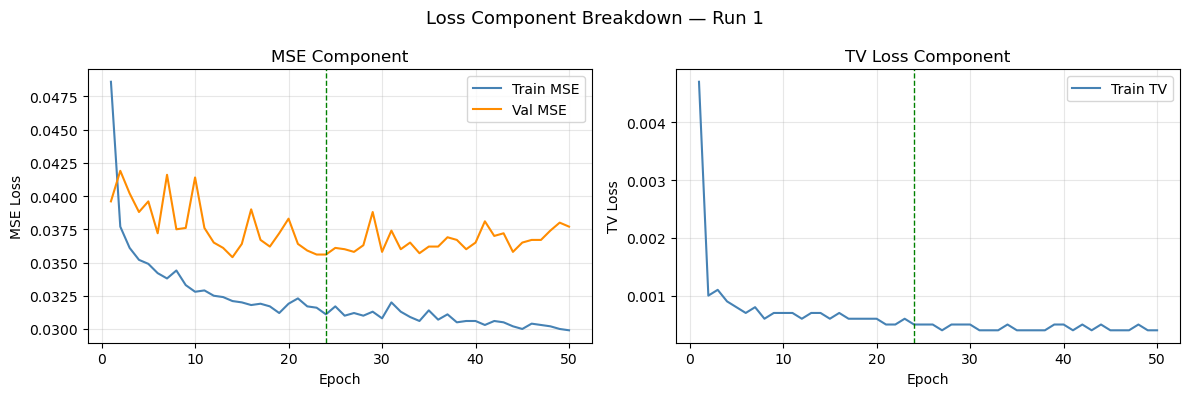

In [6]:
# ── MSE vs TV loss breakdown ───────────────────────────────────────────────
train_mse = [
    0.0486,0.0377,0.0361,0.0352,0.0349,0.0342,0.0338,0.0344,0.0333,0.0328,
    0.0329,0.0325,0.0324,0.0321,0.0320,0.0318,0.0319,0.0317,0.0312,0.0319,
    0.0323,0.0317,0.0316,0.0311,0.0317,0.0310,0.0312,0.0310,0.0313,0.0308,
    0.0320,0.0313,0.0309,0.0306,0.0314,0.0307,0.0311,0.0305,0.0306,0.0306,
    0.0303,0.0306,0.0305,0.0302,0.0300,0.0304,0.0303,0.0302,0.0300,0.0299,
]
train_tv = [round(train_losses[i] - train_mse[i], 4) for i in range(50)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_mse,  label='Train MSE', color='steelblue')
axes[0].plot(epochs, [v - (train_losses[i] - train_mse[i]) for i, v in enumerate(val_losses)],
             label='Val MSE', color='darkorange')
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1)
axes[0].set_title('MSE Component')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_tv, label='Train TV', color='steelblue')
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1)
axes[1].set_title('TV Loss Component')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('TV Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Loss Component Breakdown — Run 1', fontsize=13)
plt.tight_layout()
plt.show()

### Key Observations

- **TV loss** dropped sharply in early epochs (0.047 → ~0.005) — model learned smooth outputs quickly
- **MSE dominates** throughout — model is optimising real station prediction, not just smoothness
- **Best checkpoint at epoch 24** — val loss improved consistently to epoch 14, then marginal gains to epoch 24
- **Mild overfitting after epoch 24** — train MSE continued falling (0.0311 → 0.0299) while val MSE plateaued at ~0.036–0.038
- **Train/Val gap ~0.006 MSE** — overfitting is mild
- **Test loss (0.0332) < Val loss (0.0361)** — model generalises well to Apr–Jun 2021

In [7]:
# ── Load best checkpoint and verify ───────────────────────────────────────
checkpoint_path = BASE_DIR / 'models' / 'dual_branch_unet.pth'

if checkpoint_path.exists():
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    print(f'Checkpoint loaded from {checkpoint_path}')
    print(f'Device: {device}')
else:
    print(f'Checkpoint not found at {checkpoint_path}')
    print('Run `python train.py` first to generate the checkpoint.')

Checkpoint loaded from /Users/bikal/Documents/deep-learning/precipitation-downsampling/models/dual_branch_unet.pth
Device: mps


/var/folders/b_/_rtd6yzs2gq5_gvwcmzw268c0000gn/T/ipykernel_85229/1458559878.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_p